# Linear Regression 1 — Predict Amount

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import matplotlib.pyplot as plt


Load Dataset

In [2]:
from pathlib import Path

BASE_DIR = Path(".").resolve()

# جرّب أولاً ملف merged.csv إذا موجود
csv_path = BASE_DIR / "merged.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print("Loaded:", csv_path)
else:
    # بيانات تجريبية إذا ما عندك ملف
    df = pd.DataFrame({
        "date": pd.date_range("2026-01-01", periods=60, freq="D"),
        "category_id": np.random.randint(1, 6, size=60),
        "amount": np.random.randint(5, 50, size=60)
    })
    print("Using sample data")

df.head()


Using sample data


,date,category_id,amount
0,2026-01-01,2,13
1,2026-01-02,1,17
2,2026-01-03,5,22
3,2026-01-04,3,7
4,2026-01-05,3,22


Feature Engineering

In [3]:
# تأكد أن date نوعه datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# day_of_week: 0=Monday ... 6=Sunday
df["day_of_week"] = df["date"].dt.dayofweek

# is_weekend: Saturday/Sunday
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df[["date", "day_of_week", "is_weekend", "category_id", "amount"]].head()


,date,day_of_week,is_weekend,category_id,amount
0,2026-01-01,3,0,2,13
1,2026-01-02,4,0,1,17
2,2026-01-03,5,1,5,22
3,2026-01-04,6,1,3,7
4,2026-01-05,0,0,3,22


Prepare X, y

In [4]:
# الهدف: نتوقع amount
y = df["amount"]

# الميزات المطلوبة
X = df[["day_of_week", "category_id"]]

# إذا تريد التحدي الإضافي:
# X = df[["day_of_week", "category_id", "is_weekend"]]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (60, 2)
y shape: (60,)


Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 48
Test size: 12


Train Model (fit)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained ✅")


Model trained ✅


Predict + Metrics (MAE / R2)

In [7]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 3))
print("R2 :", round(r2, 3))


MAE: 11.839
R2 : -0.158


Plot (y_true vs y_pred)

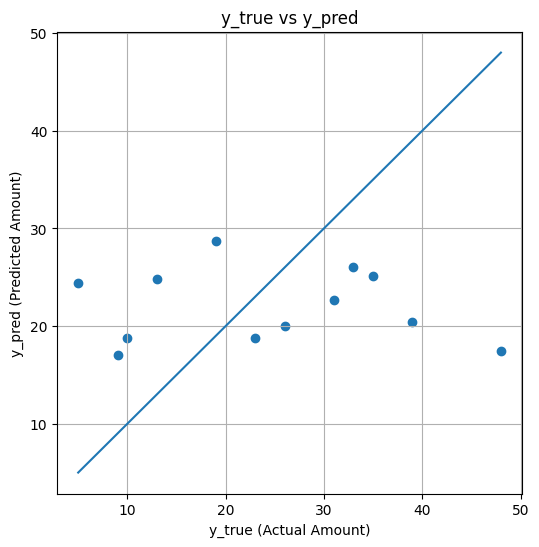

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("y_true (Actual Amount)")
plt.ylabel("y_pred (Predicted Amount)")
plt.title("y_true vs y_pred")

# خط مثالي y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.grid(True)
plt.show()


Quick Results Table

In [9]:
result_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": np.round(y_pred, 2)
}).head(10)

result_df


,y_true,y_pred
0,13,24.78
1,9,17.03
2,33,26.10
3,19,28.73
4,26,20.05
5,10,18.73
6,39,20.44
7,35,25.17
8,23,18.73
9,31,22.68
